# W02 Preprocessing Pipeline

**Platform:** Aido Rover  
**SEED:** 42  
**MAP_SEED:** 6  
**Sampling rate:** 10 Hz

Pipeline overview:
1. Synthetic dataset generation (synthetic_rover_data.csv)
2. Cleaning & data-quality report
3. FFT (torque × 4 + LiDAR × 1, 5 spectral features each)
4. PCA — 95% variance retention
5. RF feature selection

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # repo root, to import the shared world core
from rl.rover_world import RoverWorld

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Synthetic Aido Rover Dataset Generation

Generated by the shared **world core** (`rl/rover_world.py`, designed in
`W02_Rover_World_Core.ipynb`): one physically-coupled latent world drives all channels, so
the streams are correlated by physics rather than sampled independently. Here we drive the
`continue` policy with blockages OFF (the W2 detection stream) and dump the 10 channels.

In [ ]:
# ── Generate the sensor stream with the shared world core ─────────────────
N_SAMPLES = 15000
FS        = 10.0                 # Hz
DT        = 1.0 / FS
MAP_SEED  = 6                    # map/route/terrain layout
HAZARD    = 0.05                 # calibrated in Rover_World_Core (MAP_SEED=6 -> ~15% anomaly rate)

CHANNELS = ['gps_lat', 'gps_lon', 'lidar_distance', 'battery_soc',
            'torque_0', 'torque_1', 'torque_2', 'torque_3', 'ambient_temp', 'anomaly_label']

world = RoverWorld(hazard_intensity=HAZARD, seed=SEED, total_steps=N_SAMPLES, map_seed=MAP_SEED)
rows  = [world.step(0) for _ in range(N_SAMPLES)]   # 'continue' policy, blockages OFF
print(f'Generated {len(rows)} steps from the world core (MAP_SEED={MAP_SEED}, HAZARD={HAZARD})')

Generated 15000 steps from the world core (MAP_SEED=6, HAZARD=0.05)


In [3]:
# ── Timestamp index + DataFrame (channels map 1:1 from world.step output) ─────
timestamps = pd.date_range(start='2026-06-24 08:00:00', periods=N_SAMPLES,
                           freq=f'{int(DT * 1000)}ms')

df = pd.DataFrame([{c: r[c] for c in CHANNELS} for r in rows], index=timestamps)
df.index.name = 'timestamp'
df['anomaly_label'] = df['anomaly_label'].astype(int)

anomaly_mask = df['anomaly_label'].astype(bool).values      # bool view of the label (plots/summary)
print(f'Anomaly coverage: {anomaly_mask.mean()*100:.1f}%')
print(f'Normal samples  : {(~anomaly_mask).sum()}')
print(f'Anomaly samples : {anomaly_mask.sum()}')

# Simulate sensor-logging dropouts: blank 0.5% of sensor readings (cleaned downstream)
_rng_missing = np.random.default_rng(SEED)
sensor_cols = [c for c in df.columns if c != 'anomaly_label']
miss = _rng_missing.random((len(df), len(sensor_cols))) < 0.005
df[sensor_cols] = df[sensor_cols].where(~miss)

print('Channels assembled:', df.shape)

Anomaly coverage: 15.1%
Normal samples  : 12742
Anomaly samples : 2258
Channels assembled: (15000, 10)


In [4]:
out_path = DATA_DIR / 'synthetic_rover_data.csv'
df.to_csv(out_path)
print(f'Data saved to {out_path.resolve()}')

Data saved to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/synthetic_rover_data.csv


## Cleaning & Quality report



### Dataset Validation

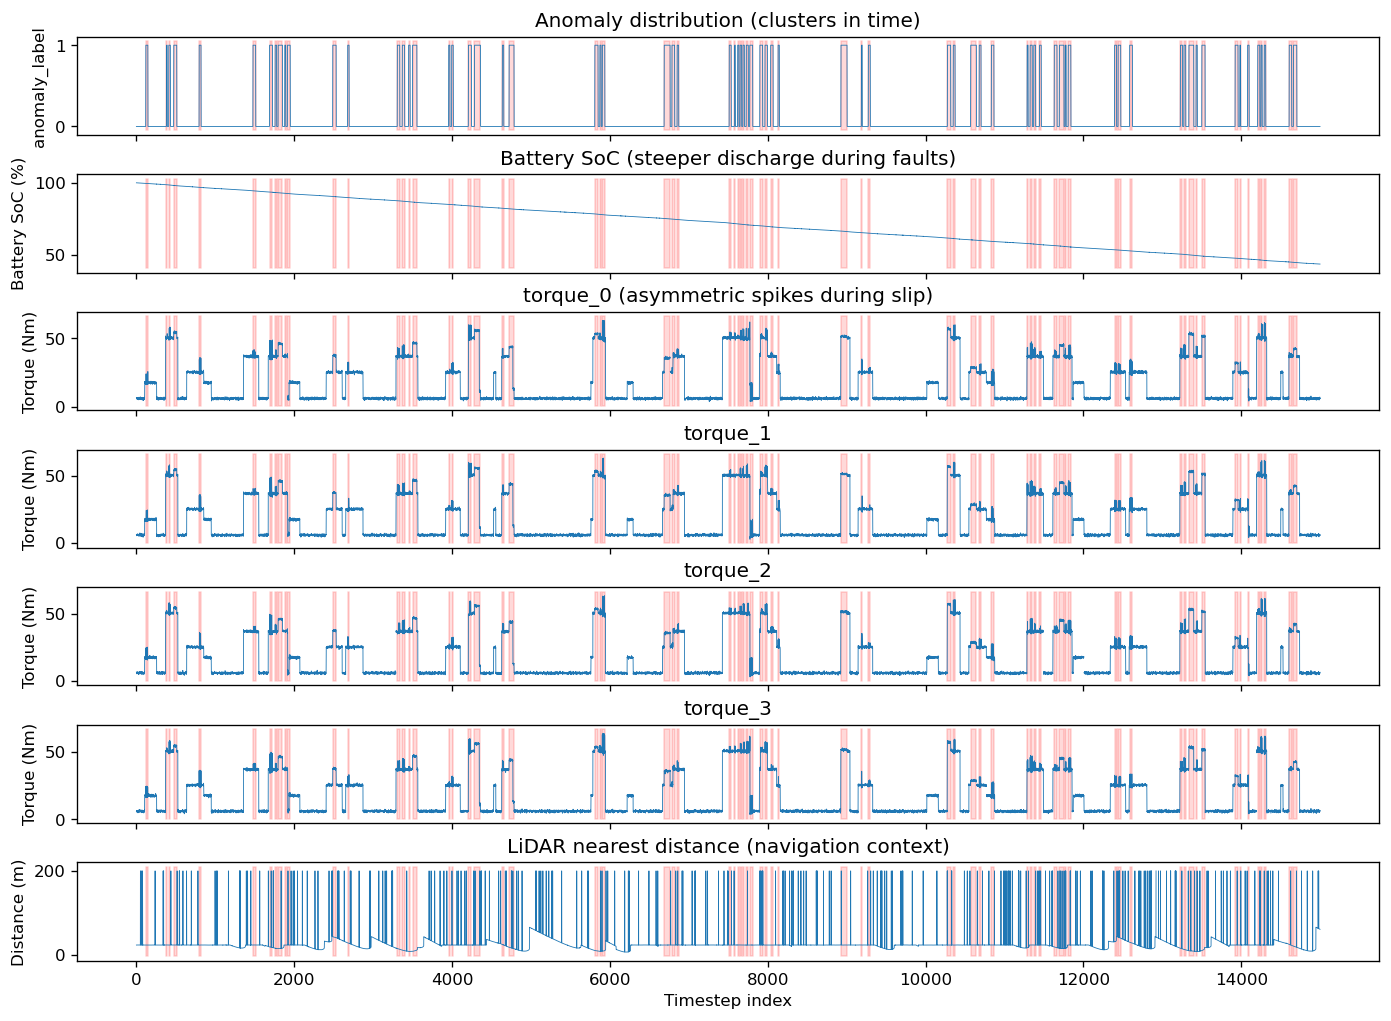

In [5]:
# ── Anomaly Distribution Plot ──────────────────────────────────
fig, axes = plt.subplots(7, 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.4)
t = np.arange(N_SAMPLES)

panels = [
    (df.anomaly_label.values, 'anomaly_label',   'Anomaly distribution (clusters in time)'),
    (df.battery_soc.values,   'Battery SoC (%)',  'Battery SoC (steeper discharge during faults)'),
    (df.torque_0.values,      'Torque (Nm)',      'torque_0 (asymmetric spikes during slip)'),
    (df.torque_1.values,      'Torque (Nm)',      'torque_1'),
    (df.torque_2.values,      'Torque (Nm)',      'torque_2'),
    (df.torque_3.values,      'Torque (Nm)',      'torque_3'),
    (df.lidar_distance.values,'Distance (m)',     'LiDAR nearest distance (navigation context)'),
]

for ax, (data, ylabel, title) in zip(axes, panels):
    ax.plot(t, data, lw=0.5)
    ax.fill_between(t, *ax.get_ylim(), where=anomaly_mask, color='red', alpha=0.15, step='mid')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[-1].set_xlabel('Timestep index')
plt.show()

### Channel distributions

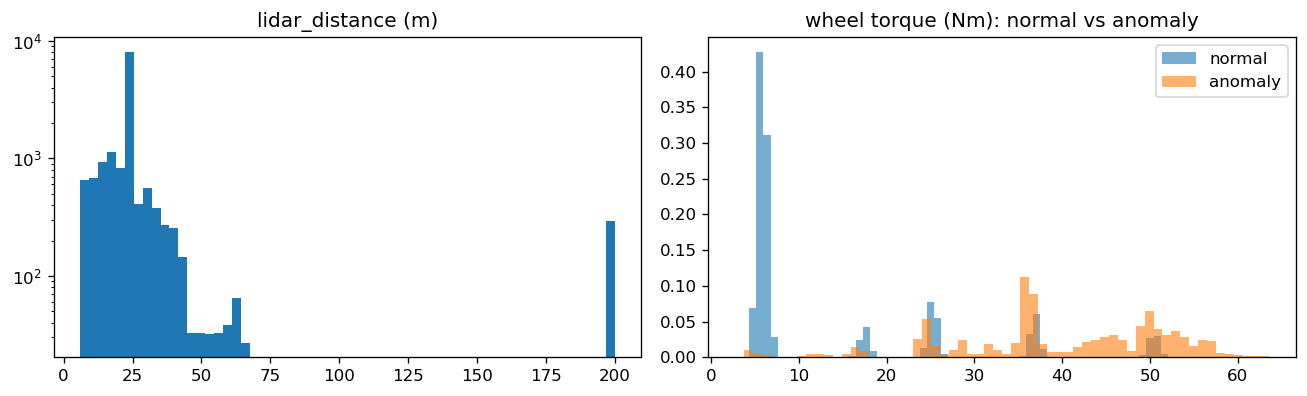

In [6]:
# ── Channel distributions (dataset validation, on the raw generated stream) ─────
tau_cols = ['torque_0', 'torque_1', 'torque_2', 'torque_3']
lab = df['anomaly_label'].to_numpy().astype(bool)
lidar = df['lidar_distance'].to_numpy(); lidar = lidar[~np.isnan(lidar)]
tau = df[tau_cols].to_numpy()
tn = tau[~lab].ravel(); tn = tn[~np.isnan(tn)]
ta = tau[lab].ravel();  ta = ta[~np.isnan(ta)]

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].hist(lidar, bins=60); axs[0].set(title='lidar_distance (m)', yscale='log')
axs[1].hist(tn, bins=60, alpha=0.6, label='normal', density=True)
axs[1].hist(ta, bins=60, alpha=0.6, label='anomaly', density=True)
axs[1].set(title='wheel torque (Nm): normal vs anomaly'); axs[1].legend()
plt.tight_layout(); plt.show()

In [7]:
# ── Dataset summary ────────────────────────────────────────
from collections import Counter
info = pd.DataFrame([r['info'] for r in rows])

print('Dataset Summary')
print(f'Total rows     : {len(df):,}')
print(f'Sampling rate  : {FS} Hz')
print(f'Duration       : {len(df) * DT / 60:.1f} min')
print(f'Anomaly %      : {anomaly_mask.mean()*100:.1f}%  (causal slip/stuck self-faults)')
print(f'Fault events   : {info[info.fault.notna()].fault.value_counts().to_dict()}')
print(f'Terrain visits : {info.terrain.value_counts().to_dict()}')
print(f'Features       : {df.shape[1] - 1} sensor channels + 1 label')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Timestamp gaps : {(df.index.to_series().diff().dropna() != pd.Timedelta("100ms")).sum()}')
df.describe().round(3)

Dataset Summary
Total rows     : 15,000
Sampling rate  : 10.0 Hz
Duration       : 25.0 min
Anomaly %      : 15.1%  (causal slip/stuck self-faults)
Fault events   : {'slip': 1369, 'stuck': 889}
Terrain visits : {'asphalt': 8705, 'dry_grass': 2077, 'wet_grass': 2044, 'mud': 1302, 'gravel': 872}
Features       : 9 sensor channels + 1 label
Missing values : 718
Duplicate rows : 0
Timestamp gaps : 0


,gps_lat,gps_lon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,anomaly_label
count,14932.000,14920.000,14919.000,14916.000,14923.000,14922.000,14925.000,14913.000,14912.000,15000.000
mean,1.351,103.801,26.270,71.748,17.856,17.836,17.872,17.853,27.997,0.151
std,0.000,0.001,25.941,16.266,15.991,15.979,16.005,16.003,2.123,0.358
min,1.350,103.800,6.100,43.452,3.576,2.751,3.016,3.463,24.705,0.000
25%,1.350,103.800,20.438,57.927,5.797,5.794,5.791,5.793,25.880,0.000
50%,1.351,103.801,23.074,72.110,6.430,6.440,6.446,6.447,27.991,0.000
75%,1.351,103.801,23.174,85.698,26.012,25.960,26.073,25.962,30.120,0.000
max,1.352,103.802,200.000,99.997,63.189,63.251,63.381,63.564,31.286,1.000


### Cleaning

In [8]:
df_raw = pd.read_csv(DATA_DIR / 'synthetic_rover_data.csv', index_col='timestamp', parse_dates=True)
sensor_cols = [c for c in df_raw.columns if c != 'anomaly_label']

null_before = df_raw[sensor_cols].isnull().sum()
print(f'Missing values before cleaning: {null_before.sum()}')

df_clean = df_raw.ffill().bfill()

quality_report = df_clean[sensor_cols].agg(['mean', 'std', 'min', 'max', 'skew', 'kurtosis']).T
quality_report['null_before'] = null_before
quality_report['null_after']  = df_clean[sensor_cols].isnull().sum()
quality_report['outliers_3std'] = (
    (df_clean[sensor_cols] - df_clean[sensor_cols].mean()).abs()
    > 3 * df_clean[sensor_cols].std()
).sum()
print('Data quality report (after cleaning):')
quality_report.round(3)

Missing values before cleaning: 718
Data quality report (after cleaning):


,mean,std,min,max,skew,kurtosis,null_before,null_after,outliers_3std
gps_lat,1.351,0.000,1.350,1.352,0.307,-1.039,68,0,0
gps_lon,103.801,0.001,103.800,103.802,0.187,-1.421,80,0,0
lidar_distance,26.281,25.956,6.100,200.000,5.961,36.946,81,0,298
battery_soc,71.738,16.265,43.452,99.997,-0.007,-1.188,84,0,0
torque_0,17.860,15.992,3.576,63.189,0.960,-0.492,77,0,0
torque_1,17.840,15.982,2.751,63.251,0.965,-0.481,78,0,0
torque_2,17.869,16.003,3.016,63.381,0.961,-0.491,75,0,0
torque_3,17.860,16.008,3.463,63.564,0.966,-0.476,87,0,0
ambient_temp,27.999,2.123,24.705,31.286,-0.000,-1.493,88,0,0


### FFT

In [9]:
from scipy.fft import rfft, rfftfreq


WINDOW = 50  # 5s at 10Hz
FFT_CHANNELS = ['torque_0', 'torque_1', 'torque_2', 'torque_3', 'lidar_distance']

def fft_features(seg, fs = FS):
    
    freqs = rfftfreq(len(seg), d=1/fs)
    mag = np.abs(rfft(seg))
    mag[0] = 0

    dom_freq    = freqs[np.argmax(mag)]
    centroid    = np.dot(freqs, mag) / (np.sum(mag) )
    bandwidth   = np.sqrt(np.dot((freqs - centroid)**2, mag) / (np.sum(mag) ))
    total_power = np.dot(mag, mag)
    peak_to_mean = np.max(mag) / (np.mean(mag))

    return [dom_freq, centroid, bandwidth, total_power, peak_to_mean]


fft_names = [f'{channel}_{feature}' 
             for channel in FFT_CHANNELS
             for feature in ['dom_freq', 'centroid', 'bandwidth', 'total_power', 'peak_to_mean']]
feature_names = sensor_cols + fft_names

rows,label = [],[]
for i in range(WINDOW, len(df_clean)):

    raw = df_clean[sensor_cols].iloc[i].values.tolist()
    fft = [v for channel in FFT_CHANNELS 
            for v in fft_features(df_clean[channel].iloc[i-WINDOW:i].values)]
    rows.append(raw + fft)
    label.append(df_clean['anomaly_label'].iloc[i])

feature_matrix= np.array(rows)
label_array = np.array(label)

print('Feature matrix preview:')
pd.DataFrame(feature_matrix[:10], columns=feature_names).round(3)

Feature matrix preview:


,gps_lat,gps_lon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,torque_0_dom_freq,...,torque_3_dom_freq,torque_3_centroid,torque_3_bandwidth,torque_3_total_power,torque_3_peak_to_mean,lidar_distance_dom_freq,lidar_distance_centroid,lidar_distance_bandwidth,lidar_distance_total_power,lidar_distance_peak_to_mean
0,1.35,103.8,23.056,99.842,7.081,6.814,6.133,6.803,28.305,4.4,...,2.2,2.484,1.419,311.898,2.010,0.2,1.751,1.444,3.555,5.643
1,1.35,103.8,200.000,99.838,5.682,6.182,6.394,6.178,28.131,4.4,...,4.4,2.454,1.438,331.360,2.204,0.2,1.750,1.434,3.510,5.631
2,1.35,103.8,23.125,99.835,5.234,5.326,6.066,5.371,28.211,4.4,...,4.4,2.430,1.446,333.300,2.035,1.2,2.601,1.442,782173.473,1.042
3,1.35,103.8,23.101,99.832,5.668,5.559,6.271,5.569,28.013,1.4,...,1.4,2.481,1.429,340.505,2.055,1.2,2.600,1.442,782136.634,1.042
4,1.35,103.8,23.109,99.829,6.415,7.310,6.970,6.811,28.088,1.4,...,1.4,2.479,1.429,335.561,2.308,1.2,2.600,1.442,782136.598,1.042
5,1.35,103.8,23.118,99.826,5.685,5.325,5.614,5.693,27.994,1.4,...,1.8,2.521,1.424,354.821,2.027,1.2,2.600,1.442,782130.083,1.042
6,1.35,103.8,23.115,99.823,6.376,6.563,6.161,6.481,28.054,1.4,...,1.8,2.508,1.428,352.712,2.096,1.2,2.600,1.442,782130.003,1.042
7,1.35,103.8,23.121,99.820,5.249,5.743,5.828,5.762,28.205,1.4,...,1.8,2.506,1.436,359.536,2.144,1.2,2.600,1.442,782125.754,1.042
8,1.35,103.8,23.104,99.817,5.321,6.260,6.437,5.905,27.955,1.4,...,1.8,2.529,1.445,353.640,2.262,1.2,2.600,1.442,782125.754,1.042
9,1.35,103.8,23.173,99.814,5.442,5.491,6.208,5.965,27.946,1.4,...,1.8,2.529,1.444,353.650,2.252,1.2,2.600,1.442,782138.463,1.042


### PCA

Components retained: 17 (from 34)
Variance explained : 0.9604


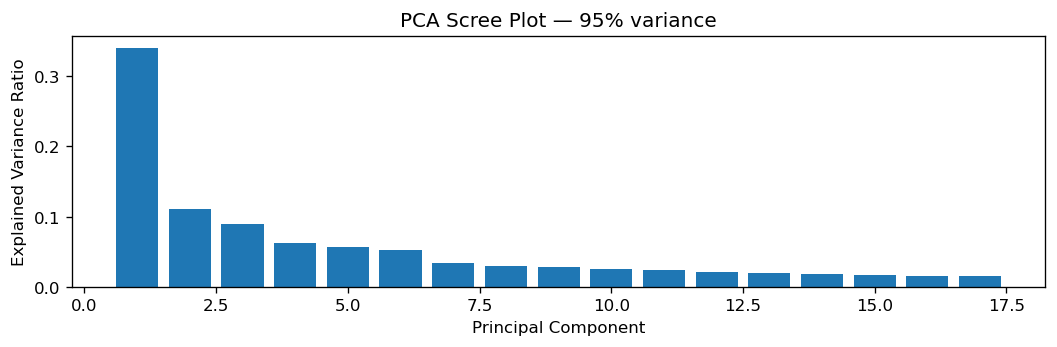

Top-5 loading features per PC:
PC1: ['torque_0_centroid', 'torque_2_centroid', 'torque_1_centroid', 'torque_3_centroid', 'torque_2_peak_to_mean']
PC2: ['torque_2', 'torque_3', 'torque_1', 'torque_0', 'torque_0_bandwidth']
PC3: ['lidar_distance_centroid', 'lidar_distance_peak_to_mean', 'lidar_distance_total_power', 'lidar_distance_dom_freq', 'lidar_distance_bandwidth']
PC4: ['torque_3_bandwidth', 'torque_1_bandwidth', 'torque_2_bandwidth', 'torque_0_bandwidth', 'torque_2_total_power']
PC5: ['torque_3_total_power', 'torque_0_bandwidth', 'torque_0_total_power', 'torque_1_total_power', 'torque_2_total_power']


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ── Stratified 70 / 15 / 15 split ─────────────────────
X_tr_raw, X_tmp, y_tr_s, y_tmp = train_test_split(
    feature_matrix, label_array, test_size=0.30, stratify=label_array, random_state=SEED)
X_va_raw, X_te_raw, y_va_s, y_te_s = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# Fit scaler and PCA on train set
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_raw)
X_va_sc = scaler.transform(X_va_raw)
X_te_sc = scaler.transform(X_te_raw)

pca = PCA(n_components=0.95, random_state=SEED)
X_tr_s = pca.fit_transform(X_tr_sc)
X_va_s = pca.transform(X_va_sc)
X_te_s = pca.transform(X_te_sc)

print(f'Components retained: {pca.n_components_} (from {X_tr_raw.shape[1]})')
print(f'Variance explained : {pca.explained_variance_ratio_.sum():.4f}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot — 95% variance')
plt.tight_layout()
plt.show()

print('Top-5 loading features per PC:')
for i in range(min(5, pca.n_components_)):
    top5 = pd.Series(np.abs(pca.components_[i]), index=feature_names).nlargest(5)
    print(f'PC{i+1}: {top5.index.tolist()}')

### RF


Stratified 70/15/15 split (PCA feature space)
  train: 10,465  |  normal=8,884  anomaly=1,581  (15.1%)
  val  :  2,242  |  normal=1,904  anomaly=338  (15.1%)
  test :  2,243  |  normal=1,904  anomaly=339  (15.1%)



Baseline RF — all 17 PCA components — val acc: 96.21%


 done.

Full-set val accuracy : 96.21%  (17 components)
2 pp threshold        : 94.21%
Minimal top-K         : 4 component(s)
Top-K val accuracy    : 94.25%  (delta = 1.96 pp)


,Component,Importance
Rank,,
1,PC2,0.2519
2,PC1,0.1234
3,PC3,0.0600
4,PC4,0.0548


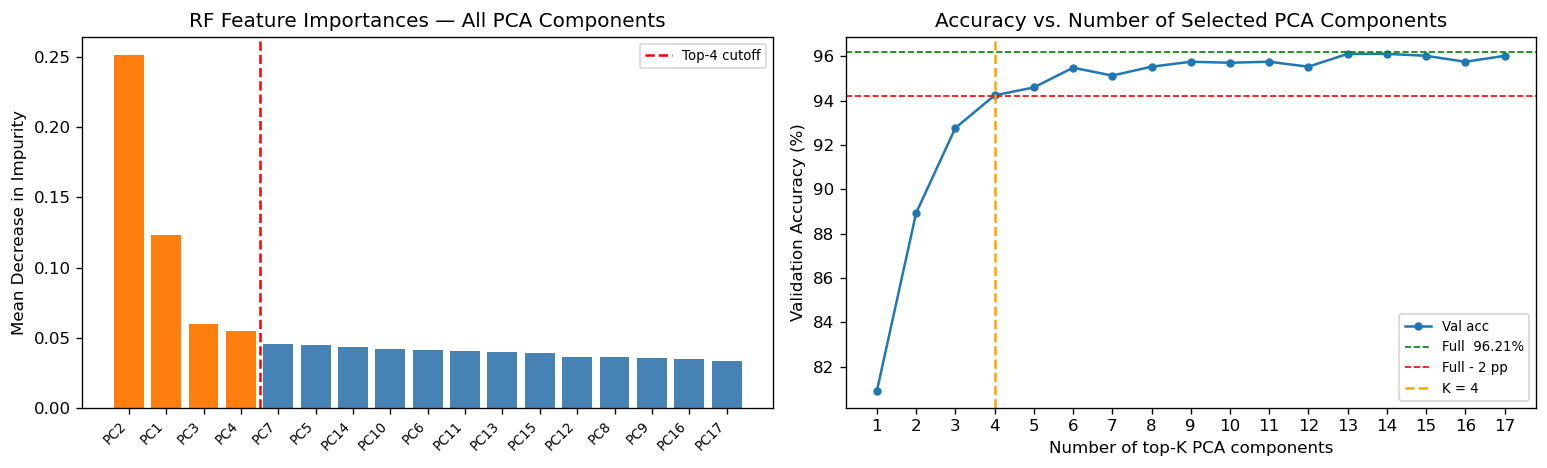


── Comparison: Aido Rover  vs.  CNC Wear Detection ──────────────────
  CNC result   : 97.81% test acc  |  2 raw sensor features (Z1 position)  |  direct feature space
  Rover result : 94.25% val acc  |  4 PCA component(s)
  delta from full-feature set : 1.96 pp
  CNC relies on raw positional features, Rover relies on a compact spectral + time-domain PCA representation.


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Split done in PCA cell; X_tr_s / X_va_s / X_te_s are PCA-transformed features
print('Stratified 70/15/15 split (PCA feature space)')
for name, y_split in [('train', y_tr_s), ('val', y_va_s), ('test', y_te_s)]:
    print(f'  {name:5s}: {len(y_split):>6,}  |  normal={(y_split==0).sum():,}  '
          f'anomaly={(y_split==1).sum():,}  ({(y_split==1).mean()*100:.1f}%)')

# ── Baseline RF on all PCA components ─────────────────────────────────────
n_pca_comps = X_tr_s.shape[1]
pca_names   = [f'PC{i+1}' for i in range(n_pca_comps)]

rf_full      = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_full.fit(X_tr_s, y_tr_s)
full_val_acc = rf_full.score(X_va_s, y_va_s)
importances  = rf_full.feature_importances_
order        = np.argsort(importances)[::-1]

print(f'\nBaseline RF — all {n_pca_comps} PCA components — val acc: {full_val_acc*100:.2f}%')

# ── Accuracy for each top-K ────────
all_k_accs = []
for k in range(1, n_pca_comps + 1):
    idx_k = order[:k]
    rf_k  = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf_k.fit(X_tr_s[:, idx_k], y_tr_s)
    all_k_accs.append(rf_k.score(X_va_s[:, idx_k], y_va_s))
print(' done.')

# ── Minimal top-K within 2 pp of full-feature accuracy ────────────────────
threshold  = full_val_acc - 0.02
best_k     = next(k + 1 for k, acc in enumerate(all_k_accs) if acc >= threshold)
best_acc_k = all_k_accs[best_k - 1]
best_idx   = order[:best_k].copy()
delta_pp   = (full_val_acc - best_acc_k) * 100

selected_names       = [pca_names[i] for i in best_idx]
selected_importances = importances[best_idx]

# ── Tabular report ─────────────────────────────────────────────────────────
print(f'\nFull-set val accuracy : {full_val_acc*100:.2f}%  ({n_pca_comps} components)')
print(f'2 pp threshold        : {threshold*100:.2f}%')
print(f'Minimal top-K         : {best_k} component(s)')
print(f'Top-K val accuracy    : {best_acc_k*100:.2f}%  (delta = {delta_pp:.2f} pp)')

feat_df = (pd.DataFrame({'Component': selected_names, 'Importance': selected_importances})
             .sort_values('Importance', ascending=False)
             .reset_index(drop=True))
feat_df.index = feat_df.index + 1
feat_df.index.name = 'Rank'
display(feat_df.round(4))

# ── Importance bar chart + accuracy-vs-K curve ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['tab:orange' if i < best_k else 'steelblue' for i in range(n_pca_comps)]
axes[0].bar(range(n_pca_comps), importances[order], color=colors)
axes[0].set_xticks(range(n_pca_comps))
axes[0].set_xticklabels([pca_names[i] for i in order], rotation=45, ha='right', fontsize=8)
axes[0].axvline(best_k - 0.5, color='red', ls='--', lw=1.5, label=f'Top-{best_k} cutoff')
axes[0].set_ylabel('Mean Decrease in Impurity')
axes[0].set_title('RF Feature Importances — All PCA Components')
axes[0].legend(fontsize=8)

axes[1].plot(range(1, n_pca_comps + 1), [a * 100 for a in all_k_accs], 'o-', ms=4, label='Val acc')
axes[1].axhline(full_val_acc * 100, color='green', ls='--', lw=1, label=f'Full  {full_val_acc*100:.2f}%')
axes[1].axhline(threshold * 100,    color='red',   ls='--', lw=1, label='Full - 2 pp')
axes[1].axvline(best_k,             color='orange', ls='--', lw=1.5, label=f'K = {best_k}')
axes[1].set_xlabel('Number of top-K PCA components')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Accuracy vs. Number of Selected PCA Components')
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, n_pca_comps + 1))

plt.tight_layout()
plt.show()

# ── Comparison to CNC benchmark ────────────────────────────────────────────
print('\n── Comparison: Aido Rover  vs.  CNC Wear Detection ──────────────────')
print(f'  CNC result   : 97.81% test acc  |  2 raw sensor features (Z1 position)  |  direct feature space')
print(f'  Rover result : {best_acc_k*100:.2f}% val acc  |  {best_k} PCA component(s)')
print(f'  delta from full-feature set : {delta_pp:.2f} pp')
print('  CNC relies on raw positional features, Rover relies on a compact spectral + time-domain PCA representation.')

In [12]:
# ── Save outputs for W02_RF_Benchmark.ipynb ────────────────────────────
TEMP_DIR = DATA_DIR / 'temp'
TEMP_DIR.mkdir(exist_ok=True)

np.save(TEMP_DIR / 'X_tr_s.npy',  X_tr_s)
np.save(TEMP_DIR / 'X_va_s.npy',  X_va_s)
np.save(TEMP_DIR / 'X_te_s.npy',  X_te_s)
np.save(TEMP_DIR / 'y_tr_s.npy',  y_tr_s)
np.save(TEMP_DIR / 'y_va_s.npy',  y_va_s)
np.save(TEMP_DIR / 'y_te_s.npy',  y_te_s)
np.save(TEMP_DIR / 'best_idx.npy', best_idx)
print(f'Saved to {TEMP_DIR.resolve()}:')

Saved to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/temp:
